In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import hashlib

In [45]:
BASE_DIR = Path("output/dnerf_ablation/trex/ablations/trex")
OUTPUT_CSV = BASE_DIR.parent / "trex_checkpoint_eval_metrics_all.csv"

SCENE_NAME = "trex"
CONFIG_PATH = "configs/dnerf_ablation/trex.yaml"
MATRIX_PRESET = "cartesian"
USE_USPLAT = False


FINAL_COLUMNS = [
    "status",
    "run_hash",
    "scene_name",
    "variant_name",
    "variant_index",
    "matrix_preset",
    "isotropy",
    "appearance",
    "sorting",
    "pruning",
    "dropout",
    "ess",
    "use_usplat",
    "config_path",
    "generated_config_path",
    "model_path",
    "checkpoint_index",
    "checkpoint_filename",
    "checkpoint_path",
    "checkpoint_name_iteration",
    "eval_requested_split",
    "eval_split_used",
    "eval_checkpoint_iteration",
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "final_gaussian_count",
    "checkpoint_size_bytes",
    "training_wall_clock_sec_at_checkpoint",
    "metrics_jsonl_path",
    "metrics_csv_path",
    "created_at",
]


def stable_hash(text: str, length: int = 16) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:length]


def parse_variant_dirname(dirname: str) -> dict:
    """
    Example:
    isotropic--rgb--sort--no_pruning--no_dropout--no_ess
    """
    parts = dirname.split("--")

    if len(parts) != 6:
        raise ValueError(f"Unexpected variant folder name: {dirname}")

    isotropy, appearance, sorting, pruning, dropout, ess = parts

    return {
        "isotropy": isotropy,
        "appearance": appearance,
        "sorting": sorting,
        "pruning": pruning,
        "dropout": dropout,
        "ess": ess,
        "variant_name": "__".join(parts),
    }


rows = []
created_at = datetime.now().replace(microsecond=0).isoformat()

variant_dirs = sorted(
    p for p in BASE_DIR.iterdir()
    if p.is_dir()
)

for variant_index, variant_dir in enumerate(variant_dirs):
    metrics_csv = variant_dir / "checkpoint_eval_metrics.csv"

    if not metrics_csv.exists():
        print(f"Skipping, no metrics file: {metrics_csv}")
        continue

    parsed = parse_variant_dirname(variant_dir.name)
    df = pd.read_csv(metrics_csv)

    for _, row in df.iterrows():
        record = row.to_dict()

        # Prefer existing CSV values, otherwise fill from folder name/defaults.
        record["run_hash"] = record.get("run_hash") or stable_hash(str(variant_dir.resolve()))
        record["scene_name"] = record.get("scene_name") or SCENE_NAME
        record["variant_name"] = parsed["variant_name"]
        record["variant_index"] = variant_index
        record["matrix_preset"] = MATRIX_PRESET

        record["isotropy"] = record.get("isotropy") or parsed["isotropy"]
        record["appearance"] = record.get("appearance") or parsed["appearance"]
        record["sorting"] = record.get("sorting") or parsed["sorting"]
        record["pruning"] = record.get("pruning") or parsed["pruning"]
        record["dropout"] = record.get("dropout") or parsed["dropout"]
        record["ess"] = record.get("ess") or parsed["ess"]

        record["use_usplat"] = USE_USPLAT
        record["config_path"] = CONFIG_PATH

        record["model_path"] = record.get("model_path") or str(variant_dir.resolve())
        record["metrics_csv_path"] = str(metrics_csv.resolve())
        record["metrics_jsonl_path"] = str((variant_dir / "checkpoint_eval_metrics.jsonl").resolve())

        # Not present in your per-run CSV; leave empty unless you add it elsewhere.
        record.setdefault("training_wall_clock_sec_at_checkpoint", pd.NA)

        record["created_at"] = created_at

        rows.append(record)

combined = pd.DataFrame(rows)

# Ensure all final columns exist.
for col in FINAL_COLUMNS:
    if col not in combined.columns:
        combined[col] = pd.NA

df = combined[FINAL_COLUMNS]

# Detect byte columns
byte_cols = [c for c in df.columns if c.endswith("_bytes") or "bytes" in c.lower()]
for col in byte_cols:
    df[col.replace("_bytes", "_mb")] = df[col] / (1024 ** 2)


In [46]:
model_spec_cols = [
    "run_hash",
    "scene_name",
    "variant_name",
    "variant_index",
    "matrix_preset",
    "isotropy",
    "appearance",
    "sorting",
    "pruning",
    "dropout",
    "ess",
    "checkpoint_index",
    "checkpoint_name_iteration",
    "eval_checkpoint_iteration",
]

metric_cols = [
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "final_gaussian_count",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
]

In [47]:
keep_cols = [c for c in model_spec_cols + metric_cols if c in df.columns]

df_clean = df[keep_cols].copy()
df_clean.head()

,run_hash,scene_name,variant_name,variant_index,matrix_preset,isotropy,appearance,sorting,pruning,dropout,...,checkpoint_name_iteration,eval_checkpoint_iteration,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,checkpoint_size_mb,training_wall_clock_sec_at_checkpoint
0,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,2000.0,2000.0,15.600895,0.842913,0.522818,3811.942397,59.685059,24242.0,6.012746,<NA>
1,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,4000.0,4000.0,20.662393,0.872304,0.202606,2408.471172,55.920898,9124.0,2.321706,<NA>
2,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,6000.0,6000.0,15.601003,0.842924,0.522782,3075.067627,57.861816,16911.0,4.221974,<NA>
3,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,8000.0,8000.0,15.600880,0.842924,0.522813,2826.625397,58.548340,19709.0,4.905568,<NA>
4,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,10000.0,10000.0,15.600850,0.842924,0.522817,3327.968093,58.665527,20139.0,5.010715,<NA>


In [51]:
df[df.isna().any(axis=1)]

,status,run_hash,scene_name,variant_name,variant_index,matrix_preset,isotropy,appearance,sorting,pruning,...,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,checkpoint_size_bytes,training_wall_clock_sec_at_checkpoint,metrics_jsonl_path,metrics_csv_path,created_at,checkpoint_size_mb
0,ok,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,...,0.522818,3811.942397,59.685059,24242.0,6304821.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,6.012746
1,ok,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,...,0.202606,2408.471172,55.920898,9124.0,2434485.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,2.321706
2,ok,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,...,0.522782,3075.067627,57.861816,16911.0,4427061.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,4.221974
3,ok,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,...,0.522813,2826.625397,58.548340,19709.0,5143861.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,4.905568
4,ok,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,...,0.522817,3327.968093,58.665527,20139.0,5254115.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,5.010715
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,ok,272e32a4ea469ff4,trex,isotropic__sh3__sort__no_pruning__no_dropout__...,31,cartesian,isotropic,sh3,sort,no_pruning,...,0.055165,340.430365,342.934570,125264.0,229080117.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,218.467824
188,ok,272e32a4ea469ff4,trex,isotropic__sh3__sort__no_pruning__no_dropout__...,31,cartesian,isotropic,sh3,sort,no_pruning,...,0.046234,306.305840,405.390137,152341.0,278576181.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,265.670949
189,ok,272e32a4ea469ff4,trex,isotropic__sh3__sort__no_pruning__no_dropout__...,31,cartesian,isotropic,sh3,sort,no_pruning,...,0.045052,312.907097,405.390137,152341.0,278576181.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,265.670949
190,ok,272e32a4ea469ff4,trex,isotropic__sh3__sort__no_pruning__no_dropout__...,31,cartesian,isotropic,sh3,sort,no_pruning,...,0.043604,318.644395,405.390137,152341.0,278576477.0,<NA>,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,/home/tebenigrelli/Notes/Work/2022-09-01_Bocco...,2026-05-05T22:44:02,265.671231


In [58]:
df_clean[[c for c in df_clean.columns if c != "training_wall_clock_sec_at_checkpoint"]].isna().sum()

cols = [c for c in df_clean.columns if c != "training_wall_clock_sec_at_checkpoint"]

df_clean[df_clean[cols].isna().any(axis=1)].to_string()

'             run_hash scene_name                                                           variant_name  variant_index matrix_preset     isotropy appearance sorting                    pruning     dropout     ess  checkpoint_index  checkpoint_name_iteration  eval_checkpoint_iteration       psnr      ssim     lpips   render_fps  peak_eval_vram_mb  final_gaussian_count  checkpoint_size_mb training_wall_clock_sec_at_checkpoint\n5    210c5ecb00688a3b       trex        anisotropic__rgb__sort__interleaved_prune_densify__dropout__ess              0     cartesian  anisotropic        rgb    sort  interleaved_prune_densify     dropout     ess               5.0                        NaN                    10000.0  15.600850  0.842924  0.522817  3326.576501          58.665527               20139.0            5.010715                                  <NA>\n11   ed654fddf7251971       trex     anisotropic__rgb__sort__interleaved_prune_densify__dropout__no_ess              1     cartesian  anisotrop

In [55]:
s = df_clean["eval_checkpoint_iteration"].to_string()

print(s)

0       2000.0
1       4000.0
2       6000.0
3       8000.0
4      10000.0
5      10000.0
6       2000.0
7       4000.0
8       6000.0
9       8000.0
10     10000.0
11     10000.0
12      2000.0
13      4000.0
14      6000.0
15      8000.0
16     10000.0
17     10000.0
18         NaN
19         NaN
20         NaN
21         NaN
22         NaN
23         NaN
24      2000.0
25      4000.0
26      6000.0
27      8000.0
28     10000.0
29     10000.0
30      2000.0
31      4000.0
32      6000.0
33      8000.0
34     10000.0
35     10000.0
36      2000.0
37      4000.0
38      6000.0
39      8000.0
40     10000.0
41     10000.0
42      2000.0
43      4000.0
44      6000.0
45      8000.0
46     10000.0
47     10000.0
48      2000.0
49      4000.0
50      6000.0
51      8000.0
52     10000.0
53     10000.0
54      2000.0
55      4000.0
56      6000.0
57      8000.0
58     10000.0
59     10000.0
60      2000.0
61      4000.0
62      6000.0
63      8000.0
64     10000.0
65     10000.0
66      20

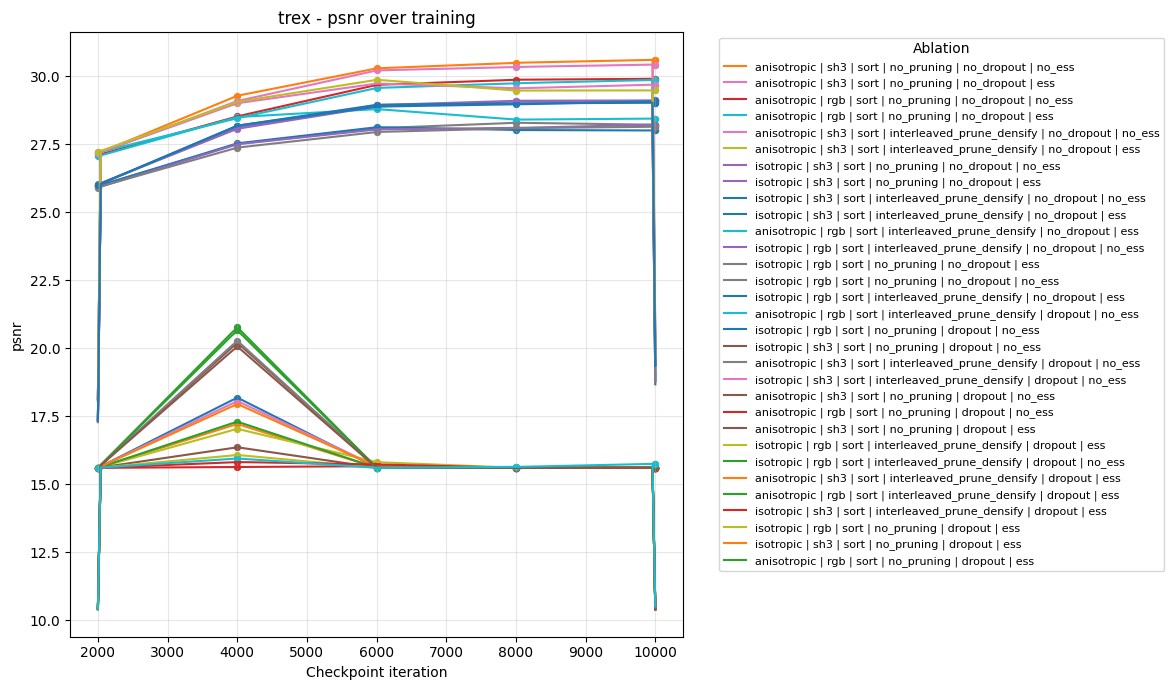

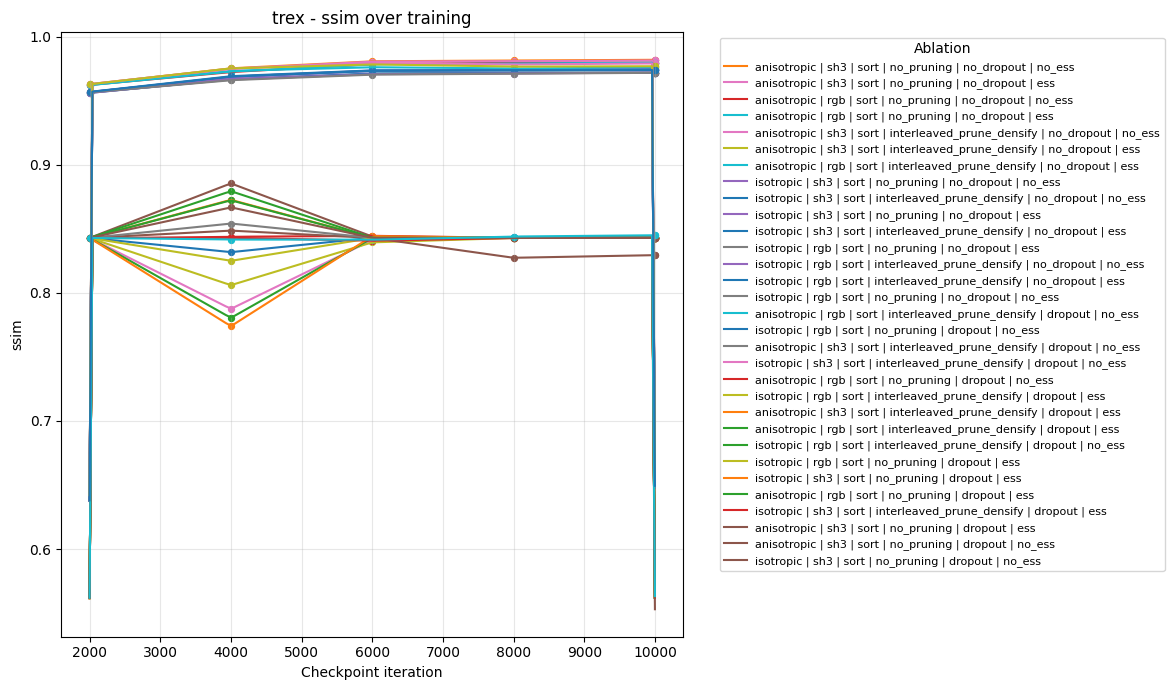

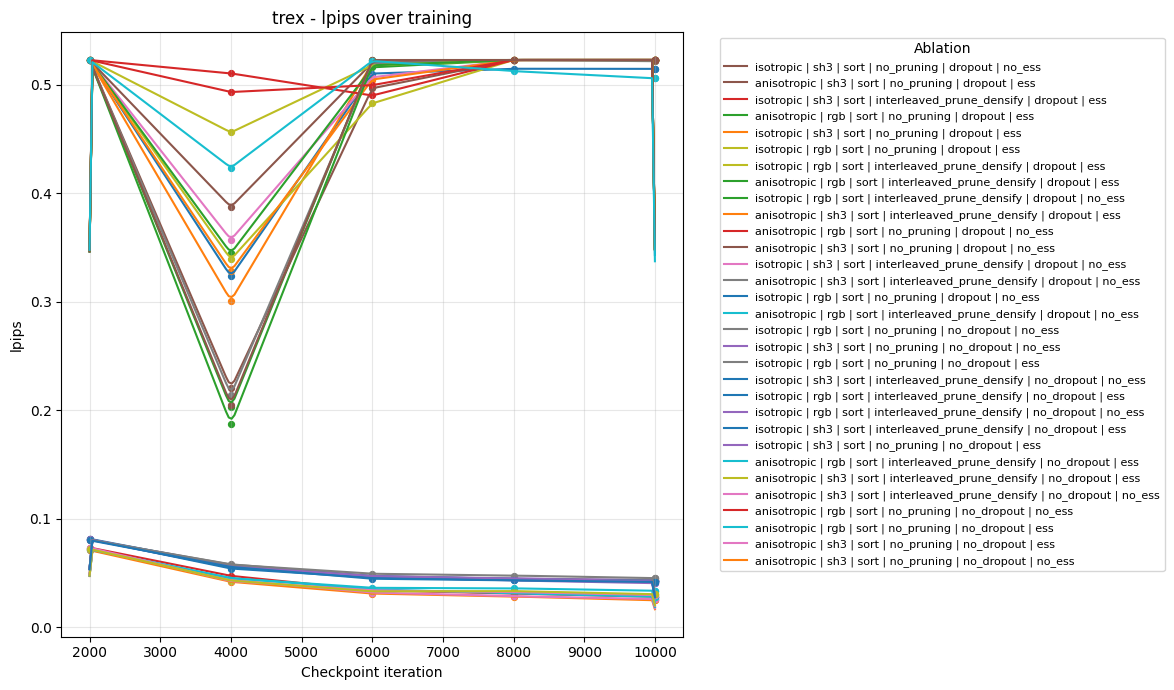

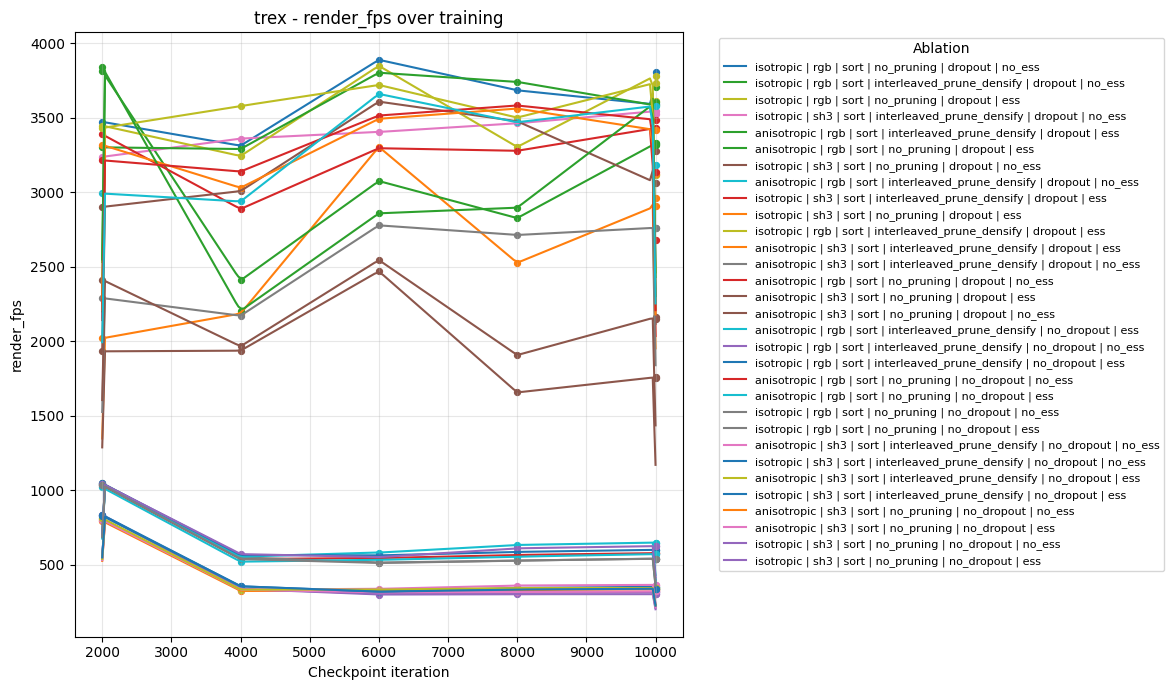

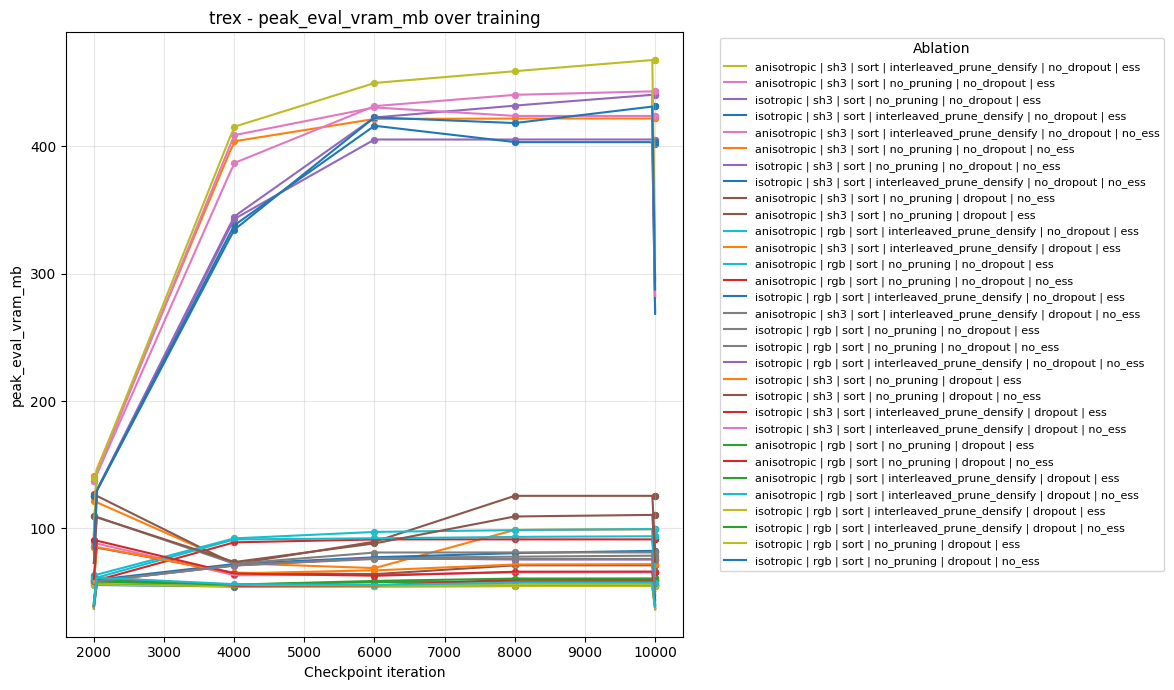

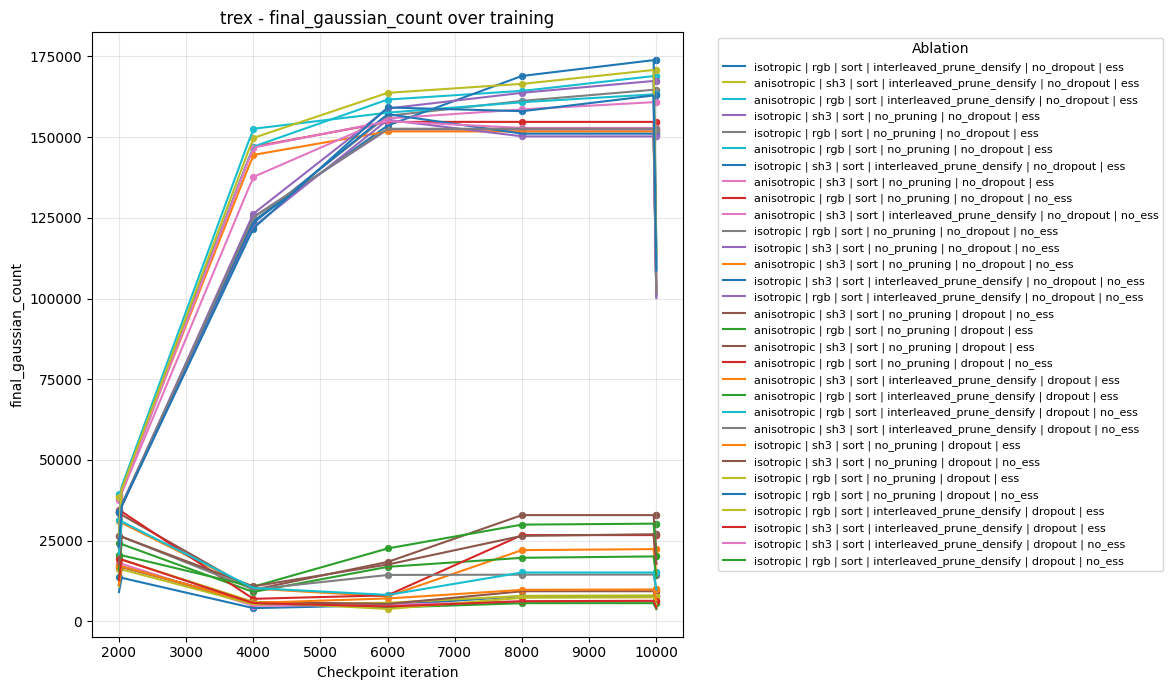

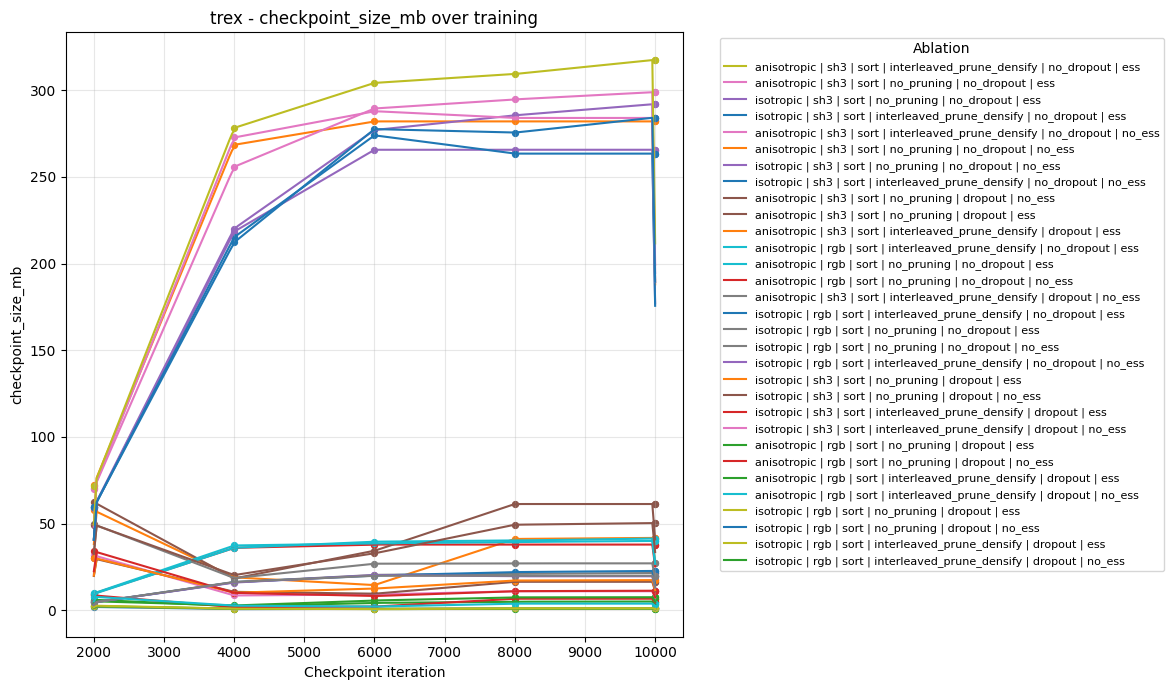

TypeError: float() argument must be a string or a real number, not 'NAType'

<Figure size 1200x700 with 0 Axes>

In [16]:
dataset_name = "trex"

plot_df = df_clean.copy()
plot_df = plot_df[plot_df["scene_name"] == dataset_name].copy()


boolean_label_map = {
    "isotropy": {
        True: "isotropy",
        False: "anisotropy",
    },
    "appearance": {
        True: "appearance",
        False: "no appearance",
    },
    "sorting": {
        True: "sorting",
        False: "no sorting",
    },
    "pruning": {
        True: "pruning",
        False: "no pruning",
    },
    "dropout": {
        True: "dropout",
        False: "no dropout",
    },
    "ess": {
        True: "ess",
        False: "no ess",
    },
}


def normalize_bool(value):
    if isinstance(value, bool):
        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, str):
        value_lower = value.strip().lower()
        if value_lower in {"true", "1", "yes", "y"}:
            return True
        if value_lower in {"false", "0", "no", "n"}:
            return False

    return None


def make_ablation_label(row):
    cols = ["isotropy", "appearance", "sorting", "pruning", "dropout", "ess"]
    parts = []

    for col in cols:
        if col not in row or pd.isna(row[col]):
            continue

        value = row[col]
        bool_value = normalize_bool(value)

        if col in boolean_label_map and bool_value is not None:
            parts.append(boolean_label_map[col][bool_value])
        else:
            parts.append(str(value))

    return " | ".join(parts)


labels = (
    plot_df
    .sort_values(["variant_index", "eval_checkpoint_iteration"])
    .groupby("run_hash")
    .first()
    .apply(make_ablation_label, axis=1)
    .to_dict()
)

plot_df["ablation_label"] = plot_df["run_hash"].map(labels)


def smooth_line_numpy(xs, ys, points=200, window=3):
    """
    Lightweight smoothing without scipy.
    Uses linear interpolation + moving average.
    """
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)

    if len(xs) < 3:
        return xs, ys

    x_smooth = np.linspace(xs.min(), xs.max(), points)
    y_interp = np.interp(x_smooth, xs, ys)

    window = max(1, int(window))
    if window <= 1:
        return x_smooth, y_interp

    kernel = np.ones(window) / window
    y_smooth = np.convolve(y_interp, kernel, mode="same")

    return x_smooth, y_smooth


def plot_metric_over_training(df, metric, x_col="eval_checkpoint_iteration"):
    plt.figure(figsize=(12, 7))

    legend_items = []

    for run_hash, run_df in df.groupby("run_hash"):
        run_df = run_df.sort_values(x_col)

        xs = run_df[x_col].to_numpy(dtype=float)
        ys = run_df[metric].to_numpy(dtype=float)

        valid = np.isfinite(xs) & np.isfinite(ys)
        xs = xs[valid]
        ys = ys[valid]

        if len(xs) == 0:
            continue

        label = run_df["ablation_label"].iloc[0]

        x_smooth, y_smooth = smooth_line_numpy(xs, ys)

        line, = plt.plot(x_smooth, y_smooth)
        plt.scatter(xs, ys, s=18, color=line.get_color())

        final_value = ys[-1]
        legend_items.append((final_value, line, label))

    plt.title(f"{dataset_name} - {metric} over training")
    plt.xlabel("Checkpoint iteration")
    plt.ylabel(metric)
    plt.grid(alpha=0.3)

    legend_items = sorted(
        legend_items,
        key=lambda item: item[0],
        reverse=True,
    )

    handles = [item[1] for item in legend_items]
    legend_labels = [item[2] for item in legend_items]

    plt.legend(
        handles,
        legend_labels,
        title="Ablation",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()


for metric in metric_cols:
    plot_metric_over_training(plot_df, metric)

In [26]:
dataset = "trex"
iteration = 10000

iter_col = "eval_checkpoint_iteration" if "eval_checkpoint_iteration" in df.columns else "checkpoint_name_iteration"

df_summary = df[
    (df["scene_name"] == dataset)
    & (df[iter_col] == iteration)
].copy()

# One record per checkpoint/run hash
dedupe_cols = ["run_hash", iter_col]
if "created_at" in df_summary.columns:
    df_summary = df_summary.sort_values("created_at")

df_summary = (
    df_summary
    .drop_duplicates(subset=dedupe_cols, keep="last")
    .sort_values(["variant_index", "variant_name"])
    .reset_index(drop=True)
)

summary_cols = [c for c in model_spec_cols + metric_cols if c in df_summary.columns]
df_summary = df_summary[summary_cols]

print("records:", len(df_summary))
print("unique run_hash:", df_summary["run_hash"].nunique())
print("iteration:", iteration)

df_summary

records: 31
unique run_hash: 31
iteration: 10000


,run_hash,scene_name,variant_name,variant_index,matrix_preset,isotropy,appearance,sorting,pruning,dropout,...,checkpoint_name_iteration,eval_checkpoint_iteration,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,checkpoint_size_mb,training_wall_clock_sec_at_checkpoint
0,210c5ecb00688a3b,trex,anisotropic__rgb__sort__interleaved_prune_dens...,0,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,NaN,10000.0,15.600850,0.842924,0.522817,3326.576501,58.665527,20139.0,5.010715,<NA>
1,ed654fddf7251971,trex,anisotropic__rgb__sort__interleaved_prune_dens...,1,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,dropout,...,NaN,10000.0,15.747937,0.844991,0.505921,3185.155138,57.422852,15155.0,3.794040,<NA>
2,51c2c11858a461e0,trex,anisotropic__rgb__sort__interleaved_prune_dens...,2,cartesian,anisotropic,rgb,sort,interleaved_prune_densify,no_dropout,...,NaN,10000.0,28.443446,0.976007,0.033688,649.901040,99.553223,169015.0,41.357577,<NA>
3,b71d198d565f4f86,trex,anisotropic__rgb__sort__no_pruning__dropout__ess,4,cartesian,anisotropic,rgb,sort,no_pruning,dropout,...,NaN,10000.0,15.600850,0.842924,0.522817,3319.379768,60.755371,30283.0,7.487277,<NA>
4,68b4e74559181e13,trex,anisotropic__rgb__sort__no_pruning__dropout__n...,5,cartesian,anisotropic,rgb,sort,no_pruning,dropout,...,NaN,10000.0,15.600856,0.842924,0.522816,2679.145412,59.870605,26740.0,6.622531,<NA>
5,9690c470a70a4586,trex,anisotropic__rgb__sort__no_pruning__no_dropout...,6,cartesian,anisotropic,rgb,sort,no_pruning,no_dropout,...,NaN,10000.0,29.864645,0.979703,0.028149,571.125826,93.866699,163302.0,39.962985,<NA>
6,233c8a127b5b6dda,trex,anisotropic__rgb__sort__no_pruning__no_dropout...,7,cartesian,anisotropic,rgb,sort,no_pruning,no_dropout,...,NaN,10000.0,29.906970,0.979859,0.028231,582.864727,91.422852,154729.0,37.869662,<NA>
7,0f134c64bfbbd882,trex,anisotropic__sh3__sort__interleaved_prune_dens...,8,cartesian,anisotropic,sh3,sort,interleaved_prune_densify,dropout,...,NaN,10000.0,15.600850,0.842924,0.522817,2959.340292,99.395996,22402.0,41.711947,<NA>
8,8996a982e9cebf97,trex,anisotropic__sh3__sort__interleaved_prune_dens...,9,cartesian,anisotropic,sh3,sort,interleaved_prune_densify,dropout,...,NaN,10000.0,15.601218,0.842929,0.521722,2758.194215,81.201172,14502.0,27.035495,<NA>
9,e505c106c20e2361,trex,anisotropic__sh3__sort__interleaved_prune_dens...,10,cartesian,anisotropic,sh3,sort,interleaved_prune_densify,no_dropout,...,NaN,10000.0,29.480149,0.976985,0.030497,344.818110,467.967773,170897.0,317.579928,<NA>


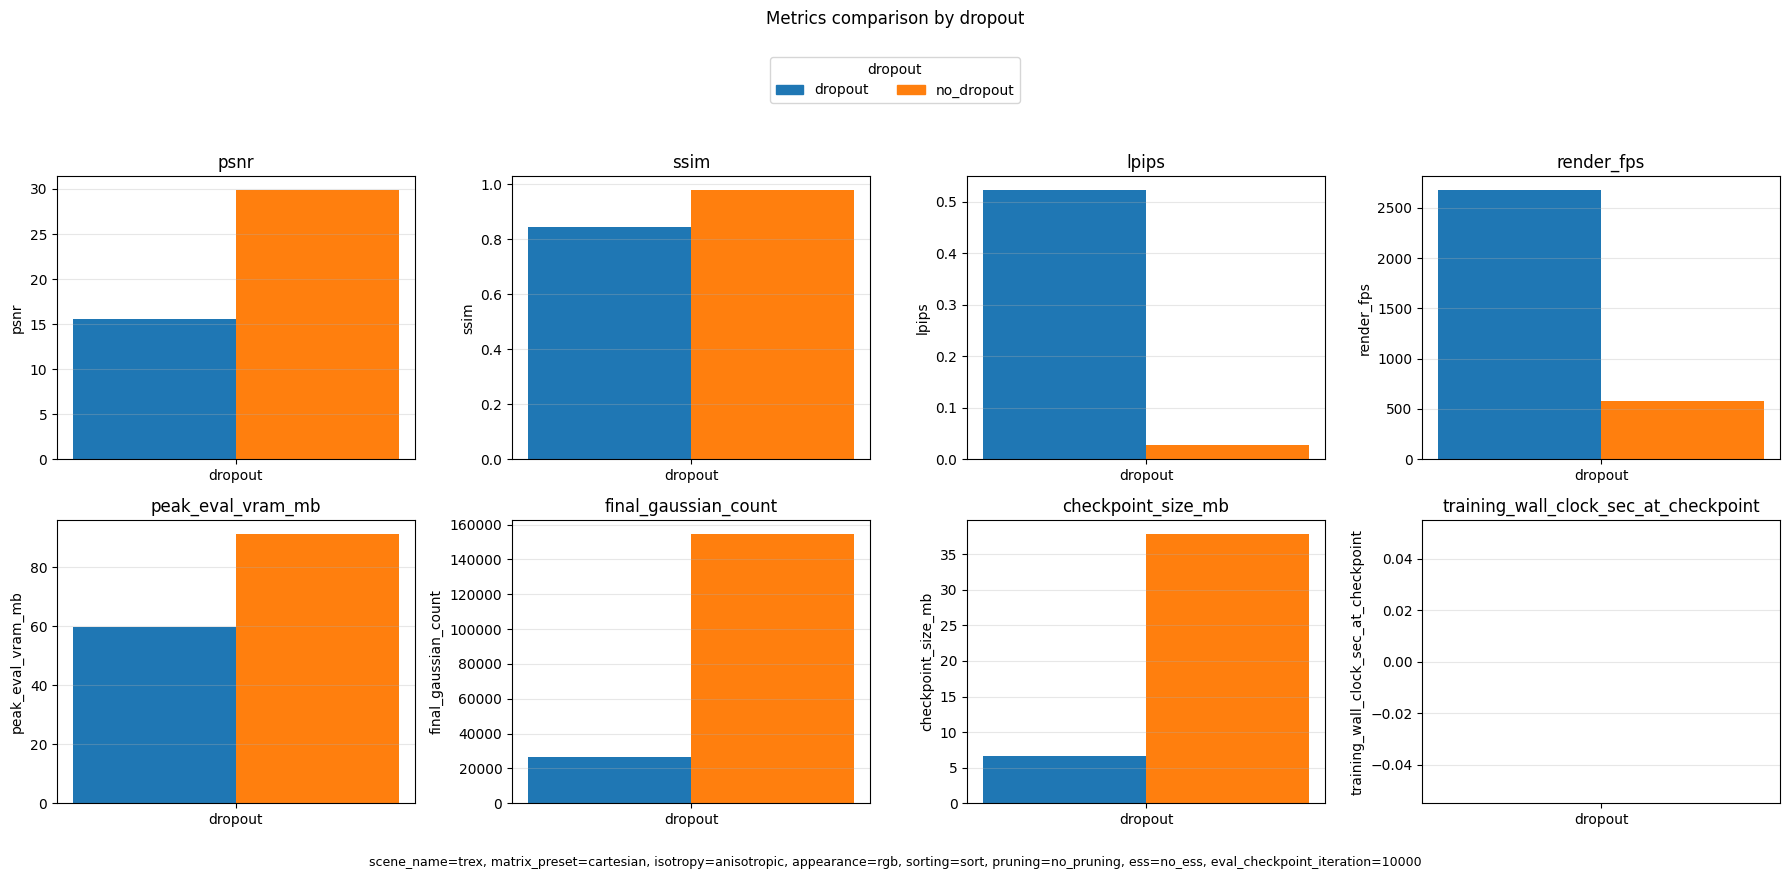

,dropout,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,final_gaussian_count,checkpoint_size_mb,training_wall_clock_sec_at_checkpoint
0,dropout,15.600856,0.842924,0.522816,2679.145412,59.870605,26740.0,6.622531,NaN
1,no_dropout,29.906970,0.979859,0.028231,582.864727,91.422852,154729.0,37.869662,NaN


In [27]:
compare_col = "dropout"

fixed_values = {
    "scene_name": "trex",
    "matrix_preset": "cartesian",
    "isotropy": "anisotropic",
    "appearance": "rgb",
    "sorting": "sort",
    "pruning": "no_pruning",
    "dropout": "no_dropout",
    "ess": "no_ess",
    "eval_checkpoint_iteration": 10000,
}

metrics_to_plot = [
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "final_gaussian_count",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
]

plot_df = df_summary.copy()

for col, val in fixed_values.items():
    if col in plot_df.columns and col != compare_col:
        plot_df = plot_df[plot_df[col] == val]

if plot_df.empty:
    raise ValueError("No rows match the selected fixed_values.")

metrics_to_plot = [m for m in metrics_to_plot if m in plot_df.columns]

agg = (
    plot_df
    .groupby(compare_col, as_index=False)[metrics_to_plot]
    .mean()
)

compare_values = agg[compare_col].astype(str).tolist()
n_values = len(compare_values)

cmap = plt.get_cmap("tab10")
colors = {
    value: cmap(i % cmap.N)
    for i, value in enumerate(compare_values)
}

max_cols = 4
n_metrics = len(metrics_to_plot)
n_cols = min(max_cols, n_metrics)
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 4 * n_rows),
    squeeze=False,
)

axes_flat = axes.ravel()

x_center = 0
bar_width = 0.8 / max(n_values, 1)
offsets = (np.arange(n_values) - (n_values - 1) / 2) * bar_width

for ax, metric in zip(axes_flat, metrics_to_plot):
    for i, value in enumerate(compare_values):
        metric_value = agg.loc[agg[compare_col].astype(str) == value, metric].iloc[0]

        ax.bar(
            x_center + offsets[i],
            metric_value,
            width=bar_width,
            color=colors[value],
            label=value,
        )

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticks([x_center])
    ax.set_xticklabels([compare_col])
    ax.grid(axis="y", alpha=0.3)

for ax in axes_flat[n_metrics:]:
    ax.axis("off")

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[value])
    for value in compare_values
]

fig.legend(
    handles,
    compare_values,
    title=compare_col,
    loc="upper center",
    ncol=min(n_values, 6),
    bbox_to_anchor=(0.5, 1.03),
)

fixed_text = ", ".join(
    f"{k}={v}"
    for k, v in fixed_values.items()
    if k != compare_col and k in df_summary.columns
)

fig.suptitle(f"Metrics comparison by {compare_col}", y=1.08)
fig.text(0.5, 0.01, fixed_text, ha="center", fontsize=9)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.show()

agg

            count  nunique     min      max
dropout                                    
dropout         6        5  2000.0  10000.0
no_dropout      6        5  2000.0  10000.0


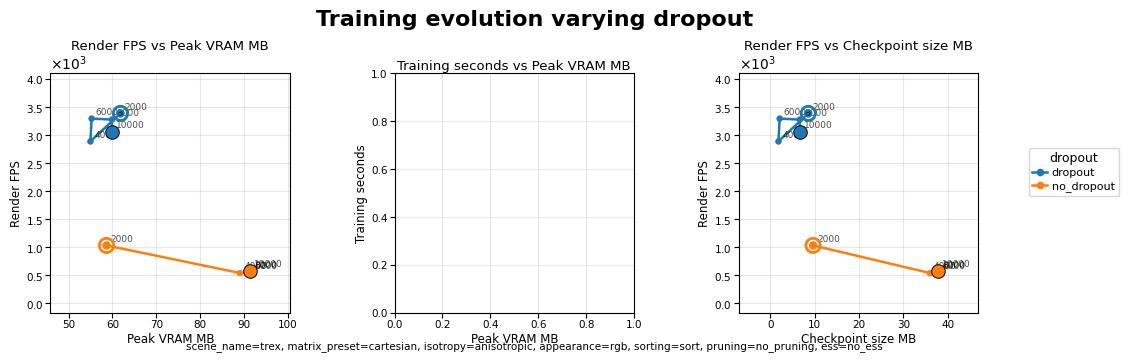

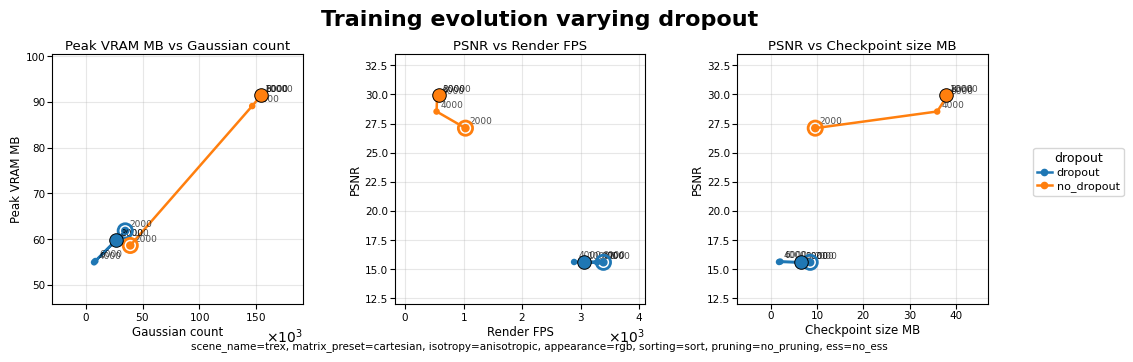

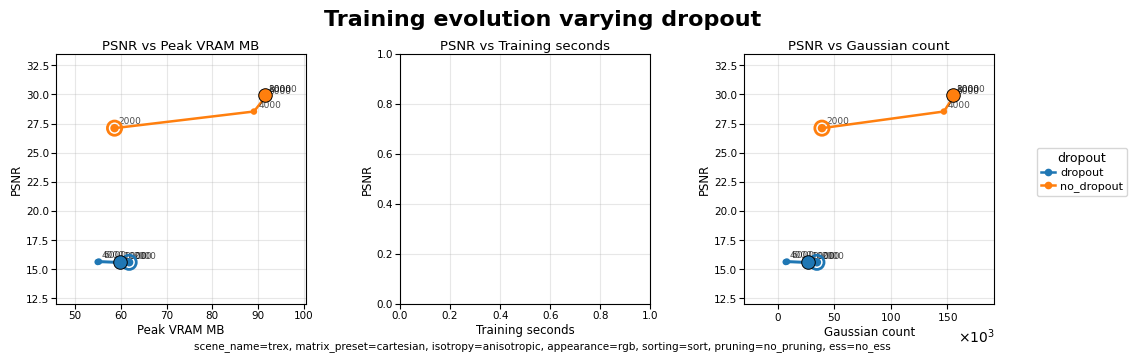

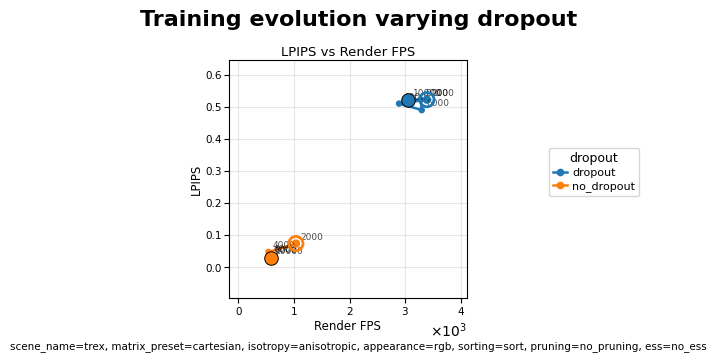

In [28]:
# %%
pareto_pairs = [
    ("peak_eval_vram_mb", "render_fps", "Peak VRAM MB", "Render FPS"),
    ("peak_eval_vram_mb", "training_wall_clock_sec_at_checkpoint", "Peak VRAM MB", "Training seconds"),
    ("checkpoint_size_mb", "render_fps", "Checkpoint size MB", "Render FPS"),
    ("final_gaussian_count", "peak_eval_vram_mb", "Gaussian count", "Peak VRAM MB"),
    ("render_fps", "psnr", "Render FPS", "PSNR"),
    ("checkpoint_size_mb", "psnr", "Checkpoint size MB", "PSNR"),
    ("peak_eval_vram_mb", "psnr", "Peak VRAM MB", "PSNR"),
    ("training_wall_clock_sec_at_checkpoint", "psnr", "Training seconds", "PSNR"),
    ("final_gaussian_count", "psnr", "Gaussian count", "PSNR"),
    ("render_fps", "lpips", "Render FPS", "LPIPS"),
]

vary_col = "dropout"

fixed_values = {
    "scene_name": "trex",
    "matrix_preset": "cartesian",
    "isotropy": "anisotropic",
    "appearance": "rgb",
    "sorting": "sort",
    "pruning": "no_pruning",
    # "dropout": "no_dropout",  # excluded because vary_col = "dropout"
    "ess": "no_ess",
}

iter_col = "eval_checkpoint_iteration"

from matplotlib.ticker import ScalarFormatter

plot_df = df_clean.copy()

for col, val in fixed_values.items():
    if col in plot_df.columns and col != vary_col:
        plot_df = plot_df[plot_df[col].astype(str) == str(val)]

if iter_col not in plot_df.columns:
    raise ValueError(f"Missing iteration column: {iter_col}")

if vary_col not in plot_df.columns:
    raise ValueError(f"Missing varying column: {vary_col}")

plot_df = plot_df.dropna(subset=[vary_col, iter_col]).copy()

available_pairs = [
    pair for pair in pareto_pairs
    if pair[0] in plot_df.columns and pair[1] in plot_df.columns
]

if not available_pairs:
    raise ValueError("No pareto pairs are available in plot_df.")

vary_values = sorted(plot_df[vary_col].astype(str).unique())

if len(vary_values) == 0:
    raise ValueError("No vary values found after filtering.")

print(
    plot_df
    .groupby(vary_col)[iter_col]
    .agg(["count", "nunique", "min", "max"])
)

cmap = plt.get_cmap("tab10")
colors = {
    value: cmap(i % cmap.N)
    for i, value in enumerate(vary_values)
}

plots_per_image = 3

fixed_text = ", ".join(
    f"{k}={v}"
    for k, v in fixed_values.items()
    if k in plot_df.columns and k != vary_col
)


class SciFormatter(ScalarFormatter):
    def __init__(self):
        super().__init__(useMathText=True)
        self.set_scientific(True)
        self.set_powerlimits((3, 3))


def use_scientific_if_large(ax):
    for axis in [ax.xaxis, ax.yaxis]:
        values = axis.get_view_interval()
        if np.nanmax(np.abs(values)) > 999:
            fmt = SciFormatter()
            axis.set_major_formatter(fmt)


def add_axis_padding(ax, x_pad_frac=0.25, y_pad_frac=0.25):
    xmin, xmax = ax.dataLim.intervalx
    ymin, ymax = ax.dataLim.intervaly

    if not np.all(np.isfinite([xmin, xmax, ymin, ymax])):
        return

    x_span = xmax - xmin
    y_span = ymax - ymin

    if x_span == 0:
        x_span = abs(xmax) if xmax != 0 else 1
    if y_span == 0:
        y_span = abs(ymax) if ymax != 0 else 1

    ax.set_xlim(xmin - x_span * x_pad_frac, xmax + x_span * x_pad_frac)
    ax.set_ylim(ymin - y_span * y_pad_frac, ymax + y_span * y_pad_frac)


def spline_xy_by_iteration(x, y, n_points=200):
    """
    Smooth a trajectory parametrically by checkpoint order.

    This works even when x is not monotonic, unlike y=f(x) splines.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2:
        return x, y

    t = np.arange(len(x), dtype=float)
    t_smooth = np.linspace(t.min(), t.max(), n_points)

    x_smooth = np.interp(t_smooth, t, x)
    y_smooth = np.interp(t_smooth, t, y)
    return x_smooth, y_smooth


for start in range(0, len(available_pairs), plots_per_image):
    pairs_chunk = available_pairs[start:start + plots_per_image]
    n_plots = len(pairs_chunk)

    fig, axes = plt.subplots(
        1,
        n_plots,
        figsize=(3.45 * n_plots + 0.75, 3.45),
        squeeze=False,
    )

    axes = axes[0]

    for ax, (x_col, y_col, x_label, y_label) in zip(axes, pairs_chunk):
        for value in vary_values:
            line_df = plot_df[plot_df[vary_col].astype(str) == value].copy()

            line_df = (
                line_df
                .groupby(iter_col, as_index=False)[[x_col, y_col]]
                .mean()
                .sort_values(iter_col)
            )

            line_df = line_df.dropna(subset=[x_col, y_col])

            if line_df.empty:
                continue

            x = line_df[x_col].to_numpy(dtype=float)
            y = line_df[y_col].to_numpy(dtype=float)
            iters = line_df[iter_col].to_numpy()

            if len(x) >= 2:
                x_smooth, y_smooth = spline_xy_by_iteration(x, y)

                ax.plot(
                    x_smooth,
                    y_smooth,
                    linewidth=1.8,
                    color=colors[value],
                    label=value,
                    zorder=2,
                )

            ax.scatter(
                x,
                y,
                s=22,
                color=colors[value],
                edgecolors="none",
                zorder=3,
            )

            # Start marker: hollow double ring
            ax.scatter(
                x[0],
                y[0],
                s=105,
                facecolors="none",
                edgecolors=[colors[value]],
                linewidths=2.0,
                zorder=4,
            )
            ax.scatter(
                x[0],
                y[0],
                s=24,
                facecolors="none",
                edgecolors=[colors[value]],
                linewidths=1.15,
                zorder=5,
            )

            # End marker: filled with black edge
            ax.scatter(
                x[-1],
                y[-1],
                s=95,
                color=colors[value],
                edgecolors="black",
                linewidths=0.7,
                zorder=6,
            )

            for xi, yi, iteration_value in zip(x, y, iters):
                ax.annotate(
                    str(int(iteration_value)),
                    (xi, yi),
                    textcoords="offset points",
                    xytext=(3, 3),
                    fontsize=6.5,
                    alpha=0.7,
                )

        add_axis_padding(ax, x_pad_frac=0.25, y_pad_frac=0.25)
        use_scientific_if_large(ax)

        ax.set_box_aspect(1)
        ax.set_title(f"{y_label} vs {x_label}", fontsize=9.5, pad=3)
        ax.set_xlabel(x_label, fontsize=8.5, labelpad=2)
        ax.set_ylabel(y_label, fontsize=8.5, labelpad=2)
        ax.tick_params(axis="both", labelsize=7.5, pad=1.5)
        ax.grid(alpha=0.3)

    handles = [
        plt.Line2D(
            [0],
            [0],
            color=colors[value],
            marker="o",
            linewidth=1.8,
            markersize=4.5,
            label=value,
        )
        for value in vary_values
    ]

    fig.legend(
        handles=handles,
        labels=vary_values,
        title=vary_col,
        loc="center left",
        bbox_to_anchor=(0.94, 0.52),
        ncol=1,
        frameon=True,
        fontsize=8,
        title_fontsize=9,
        borderpad=0.35,
        labelspacing=0.3,
        handlelength=1.3,
        handletextpad=0.45,
    )

    fig.suptitle(
        f"Training evolution varying {vary_col}",
        y=0.99,
        fontsize=16,
        fontweight="bold",
    )

    fig.text(
        0.5,
        0.006,
        fixed_text,
        ha="center",
        fontsize=7.5,
    )

    plt.tight_layout(
        rect=[0.002, 0.028, 0.925, 0.955],
        pad=0.15,
        w_pad=0.25,
        h_pad=0.0,
    )

    plt.show()

,dropout,psnr,ssim,lpips,render_fps,peak_eval_vram_mb,checkpoint_size_mb,training_wall_clock_sec_at_checkpoint,final_gaussian_count
0,dropout,15.615852,0.843287,0.515302,3159.795153,58.604899,5.378626,NaN,21646.666667
1,no_dropout,29.166119,0.975486,0.040427,641.130358,85.570231,32.847416,NaN,134157.833333


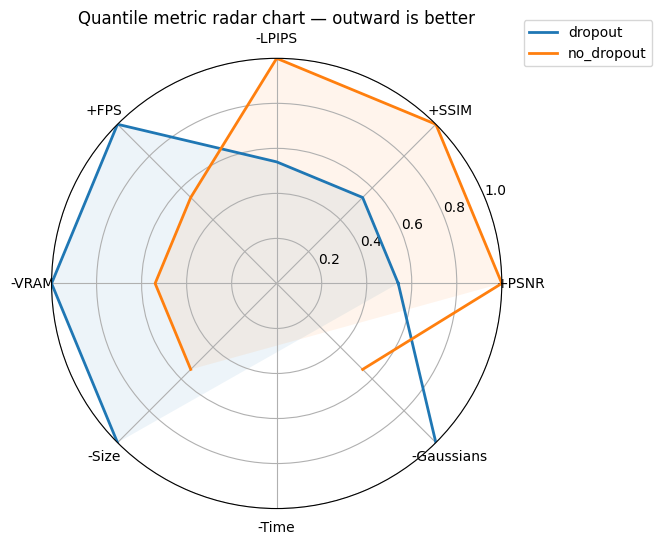

In [29]:
# %%
vary_col = "dropout"

fixed_values = {
    "scene_name": "trex",
    "matrix_preset": "cartesian",
    "isotropy": "anisotropic",
    "appearance": "rgb",
    "sorting": "sort",
    "pruning": "no_pruning",
    # "dropout": "no_dropout",  # excluded because vary_col = "dropout"
    "ess": "no_ess",
}

display_cols = [
    "psnr",
    "ssim",
    "lpips",
    "render_fps",
    "peak_eval_vram_mb",
    "checkpoint_size_mb",
    "training_wall_clock_sec_at_checkpoint",
    "final_gaussian_count",
]

radar_specs = {
    "+PSNR": {
        "col": "psnr",
        "higher_is_better": True,
    },
    "+SSIM": {
        "col": "ssim",
        "higher_is_better": True,
    },
    "-LPIPS": {
        "col": "lpips",
        "higher_is_better": False,
    },
    "+FPS": {
        "col": "render_fps",
        "higher_is_better": True,
    },
    "-VRAM": {
        "col": "peak_eval_vram_mb",
        "higher_is_better": False,
    },
    "-Size": {
        "col": "checkpoint_size_mb",
        "higher_is_better": False,
    },
    "-Time": {
        "col": "training_wall_clock_sec_at_checkpoint",
        "higher_is_better": False,
    },
    "-Gaussians": {
        "col": "final_gaussian_count",
        "higher_is_better": False,
    },
}

quantile_floor = 0.08

plot_df = df_clean.copy()

for col, val in fixed_values.items():
    if col in plot_df.columns and col != vary_col:
        plot_df = plot_df[plot_df[col].astype(str) == str(val)]

if vary_col not in plot_df.columns:
    raise ValueError(f"Missing varying column: {vary_col}")

available_display_cols = [
    col for col in display_cols
    if col in plot_df.columns
]

if not available_display_cols:
    raise ValueError("No display columns are available in plot_df.")

available_radar_specs = {
    label: spec
    for label, spec in radar_specs.items()
    if spec["col"] in plot_df.columns
}

if not available_radar_specs:
    raise ValueError("No radar columns are available in plot_df.")

plot_df = plot_df.dropna(subset=[vary_col]).copy()

summary_df = (
    plot_df
    .groupby(vary_col, as_index=False)[available_display_cols]
    .mean()
)

display(summary_df[[vary_col] + available_display_cols])

def quantile_score(x, higher_is_better=True, floor=0.08):
    x = pd.to_numeric(x, errors="coerce")

    ranks = x.rank(
        method="average",
        pct=True,
        ascending=higher_is_better,
    )

    return floor + (1.0 - floor) * ranks

radar_cols = {}

for label, spec in available_radar_specs.items():
    radar_cols[label] = quantile_score(
        summary_df[spec["col"]],
        higher_is_better=spec["higher_is_better"],
        floor=quantile_floor,
    )

radar = pd.DataFrame(radar_cols)
radar["label"] = summary_df[vary_col].astype(str)

categories = list(radar_cols.keys())
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)

for _, row in radar.iterrows():
    values = row[categories].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["label"])
    ax.fill(angles, values, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title("Quantile metric radar chart — outward is better")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

plt.tight_layout()
plt.show()

In [30]:
# %%
import matplotlib.colors as mcolors

def plot_grouped_quantile_heatmap(
    df,
    filter_values,
    model_spec_cols,
    metric_cols,
    high_better_cols=None,
    low_better_cols=None,
    group_cols=None,
    heatmap_cols=None,
    dedupe=True,
    cell_fontsize=6,
    xtick_fontsize=8,
    ytick_fontsize=7.5,
    cell_sigfigs=2,
    cmap_name="RdYlGn",
    title_prefix="Grouped heatmap",
):
    high_better_cols = set(high_better_cols or {
        "psnr",
        "ssim",
        "render_fps",
        "fps",
    })

    low_better_cols = set(low_better_cols or {
        "lpips",
        "peak_eval_vram_mb",
        "checkpoint_size_mb",
        "training_wall_clock_sec_at_checkpoint",
        "final_gaussian_count",
        "vram",
        "size",
        "time",
        "gaussians",
    })

    df_heat = df.copy()

    for col, value in filter_values:
        if col not in df_heat.columns:
            raise ValueError(f"Missing filter column: {col}")

        if isinstance(value, (list, tuple, set)):
            df_heat = df_heat[df_heat[col].isin(value)]
        else:
            df_heat = df_heat[df_heat[col] == value]

    if df_heat.empty:
        raise ValueError("No rows left after filtering.")

    iter_col = (
        "eval_checkpoint_iteration"
        if "eval_checkpoint_iteration" in df_heat.columns
        else "checkpoint_name_iteration"
    )

    if dedupe:
        dedupe_cols = [c for c in ["run_hash", iter_col] if c in df_heat.columns]

        if dedupe_cols:
            if "created_at" in df_heat.columns:
                df_heat = df_heat.sort_values("created_at")

            df_heat = df_heat.drop_duplicates(subset=dedupe_cols, keep="last")

    fixed_cols = {col for col, _ in filter_values}

    if group_cols is None:
        group_cols = [
            c for c in model_spec_cols
            if c in df_heat.columns
            and c not in fixed_cols
            and c not in {"run_hash", "created_at"}
            and df_heat[c].nunique(dropna=False) > 1
        ]
    else:
        group_cols = [c for c in group_cols if c in df_heat.columns]

    if not group_cols:
        raise ValueError("No grouping columns found. Pass group_cols manually.")

    if heatmap_cols is None:
        heatmap_cols = [
            c for c in metric_cols
            if c in df_heat.columns
            and pd.api.types.is_numeric_dtype(df_heat[c])
        ]
    else:
        heatmap_cols = [
            c for c in heatmap_cols
            if c in df_heat.columns
            and pd.api.types.is_numeric_dtype(df_heat[c])
        ]

    if not heatmap_cols:
        raise ValueError("No numeric heatmap columns available.")

    df_grouped = (
        df_heat
        .groupby(group_cols, dropna=False, as_index=False)[heatmap_cols]
        .mean()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )

    def quantile_best_score(s, col):
        s = pd.to_numeric(s, errors="coerce")

        if col in low_better_cols:
            return s.rank(method="average", pct=True, ascending=False)

        return s.rank(method="average", pct=True, ascending=True)

    heatmap_scores = pd.DataFrame(
        {
            col: quantile_best_score(df_grouped[col], col)
            for col in heatmap_cols
        },
        index=df_grouped.index,
    )

    mean_quantile_score = heatmap_scores.mean(axis=1, skipna=True)

    sort_order = (
        mean_quantile_score
        .sort_values(ascending=False)
        .index
    )

    df_grouped = df_grouped.loc[sort_order].reset_index(drop=True)
    heatmap_scores = heatmap_scores.loc[sort_order].reset_index(drop=True)
    mean_quantile_score = mean_quantile_score.loc[sort_order].reset_index(drop=True)

    row_labels = (
        df_grouped[group_cols]
        .astype(str)
        .agg(" | ".join, axis=1)
    )

    filter_text = ", ".join(
        f"{col}={value}"
        for col, value in filter_values
    )

    fig_width = max(8, 0.7 * len(heatmap_cols))
    fig_height = max(4.5, 0.34 * len(df_grouped))

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=0, vmax=1)

    im = ax.imshow(
        heatmap_scores.to_numpy(dtype=float),
        aspect="auto",
        cmap=cmap,
        norm=norm,
    )

    ax.set_xticks(np.arange(len(heatmap_cols)))
    ax.set_xticklabels(
        heatmap_cols,
        rotation=45,
        ha="right",
        fontsize=xtick_fontsize,
    )

    ax.set_yticks(np.arange(len(df_grouped)))
    ax.set_yticklabels(row_labels, fontsize=ytick_fontsize)

    for i in range(len(df_grouped)):
        for j, col in enumerate(heatmap_cols):
            value = df_grouped.iloc[i][col]

            if pd.isna(value):
                text = ""
            else:
                text = f"{value:.{cell_sigfigs}g}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=cell_fontsize,
                color="black",
            )

    ax.set_title(
        f"{title_prefix}\n"
        f"Filtered to: {filter_text}\n"
        f"Rows sorted by mean column-wise quantile score",
        fontsize=12,
        pad=12,
    )

    cbar = fig.colorbar(
        im,
        ax=ax,
        fraction=0.032,
        pad=0.015,
        shrink=1.0,
        aspect=22,
    )
    cbar.set_label("Column-wise quantile score", rotation=270, labelpad=16)

    plt.tight_layout()
    plt.show()

    df_grouped = df_grouped.copy()
    df_grouped.insert(0, "mean_quantile_score", mean_quantile_score)

    return df_grouped, heatmap_scores

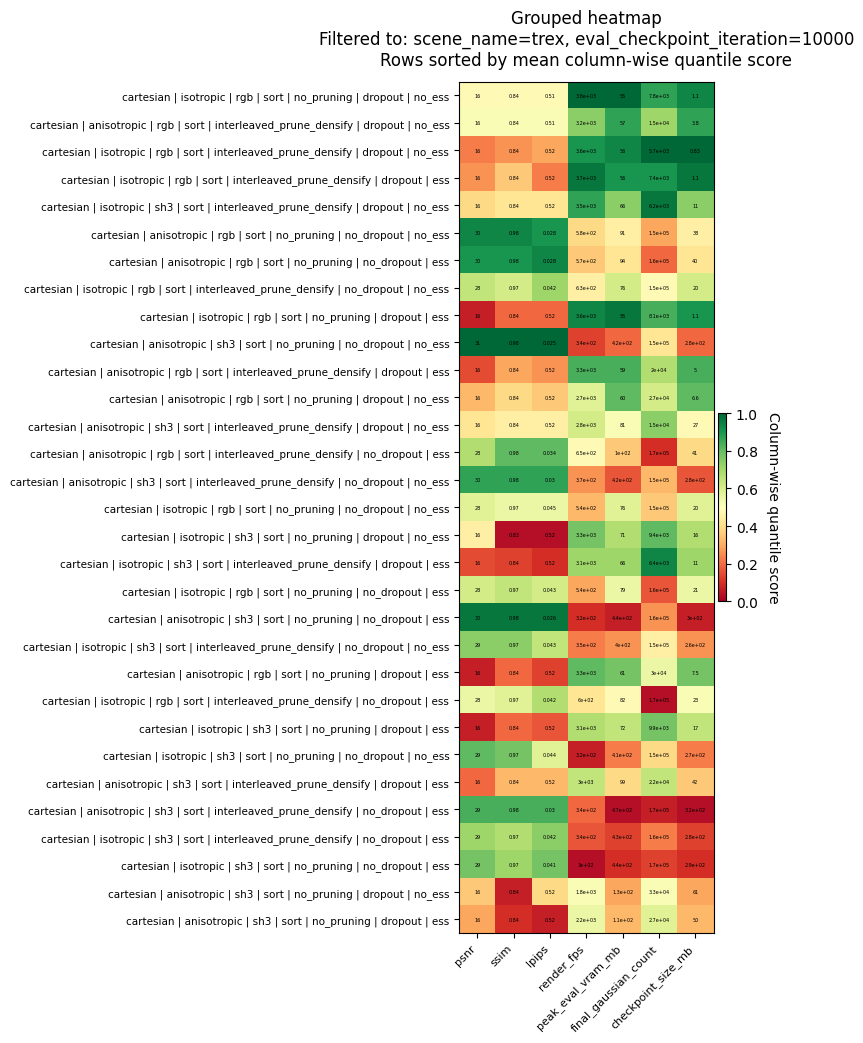

In [31]:
df_grouped, heatmap_scores = plot_grouped_quantile_heatmap(
    df=df,
    filter_values=[
        ("scene_name", "trex"),
        (iter_col, 10000),
    ],
    model_spec_cols=model_spec_cols,
    metric_cols=metric_cols,
    group_cols=[
        "matrix_preset",
        "isotropy",
        "appearance",
        "sorting",
        "pruning",
        "dropout",
        "ess",
    ],
    cell_fontsize=3.5,
)